# Phase 3: Rolling Forecast Models
**Walk-forward evaluation:** For each trading day T from Jan 2026 onward, train on all data up to T-1, predict day T. This gives ~70 predictions across three regimes.

**Regimes:**
- Pre-buildup: before Jan 15 2026 (baseline calm)
- Buildup: Jan 15 – Mar 3 2026 (tensions rising)
- Crisis: Mar 4 2026 onward (strait closed)

**Five LSTM variants:**

| Model | Features |
|-------|----------|
| A | Price only (baseline) |
| B | Price + best single sentiment (FinBERT-Tone) |
| C | Price + article volume |
| D | Price + model consensus |
| E | Price + all NLP features |

In [23]:
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from copy import deepcopy

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"Device: {DEVICE}")

# Dates
CRISIS_DATE = "2026-03-04"
BUILDUP_START = "2026-01-15"   # from Phase 2: first alarms triggered mid-Jan
FORECAST_START = "2026-01-02"  # first day we predict

# LSTM config
LOOKBACK = 30
HIDDEN_SIZE = 64
NUM_LAYERS = 2
LR = 0.001

# Rolling config
INITIAL_EPOCHS = 80    # full training on first window
RETRAIN_EPOCHS = 15    # warm-start fine-tune on subsequent days
PATIENCE = 10
RETRAIN_EVERY = 5      # retrain every N trading days (predict daily between)

os.makedirs("plots", exist_ok=True)
os.makedirs("models", exist_ok=True)

np.random.seed(42)
torch.manual_seed(42)

Device: cuda


---
## 1. Prepare Data

In [24]:
prices = pd.read_csv("data/oil_prices.csv")
prices["date"] = pd.to_datetime(prices["date"])
prices = prices.sort_values("date").reset_index(drop=True)

daily_sent = pd.read_csv("data/daily_sentiment.csv", index_col=0, parse_dates=True)

# Build unified frame on trading days
df = prices[["date", "brent_close", "brent_daily_return", "brent_volatility_5d",
             "brent_ma_20", "brent_ma_50", "brent_wti_spread"]].copy()
df = df.set_index("date")

sent_cols = [
    "finbert_tone_mean", "finbert_mean", "distilroberta_fin_mean",
    "roberta_general_mean", "vader_mean",
    "article_count", "volume_7d",
    "model_disagreement", "disagreement_7d",
    "fin_model_disagreement", "fin_disagreement_7d",
]
sent_cols = [c for c in sent_cols if c in daily_sent.columns]
df = df.join(daily_sent[sent_cols], how="left")
df[sent_cols] = df[sent_cols].ffill().fillna(0)

# Consensus features
df["consensus"] = 1 - df["disagreement_7d"]
df["fin_consensus"] = 1 - df["fin_disagreement_7d"]

df = df.dropna(subset=["brent_close", "brent_ma_50"])

print(f"Total trading days: {len(df)}")
print(f"Range: {df.index.min().date()} to {df.index.max().date()}")

Total trading days: 1024
Range: 2022-03-15 to 2026-04-09


In [25]:
PRICE_FEATURES = ["brent_close", "brent_daily_return", "brent_volatility_5d",
                  "brent_ma_20", "brent_ma_50", "brent_wti_spread"]

MODEL_CONFIGS = {
    "A_price_only": PRICE_FEATURES,
    "B_sentiment": PRICE_FEATURES + ["finbert_tone_mean"],
    "C_volume": PRICE_FEATURES + ["article_count", "volume_7d"],
    "D_consensus": PRICE_FEATURES + ["consensus", "fin_consensus"],
    "E_all": PRICE_FEATURES + [
        "finbert_tone_mean", "finbert_mean", "distilroberta_fin_mean",
        "roberta_general_mean", "vader_mean",
        "article_count", "volume_7d",
        "consensus", "fin_consensus",
    ],
}

# Forecast dates: every trading day from FORECAST_START onward
forecast_dates = df.index[df.index >= FORECAST_START]
print(f"Forecast period: {len(forecast_dates)} trading days")
print(f"  {forecast_dates[0].date()} to {forecast_dates[-1].date()}")

for name, feats in MODEL_CONFIGS.items():
    print(f"  {name}: {len(feats)} features")

Forecast period: 67 trading days
  2026-01-02 to 2026-04-09
  A_price_only: 6 features
  B_sentiment: 7 features
  C_volume: 8 features
  D_consensus: 8 features
  E_all: 15 features


---
## 2. LSTM Architecture

In [26]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.fc(lstm_out[:, -1, :])


def make_sequences(data, lookback, return_col_idx=0):
    """Build sequences where target is next-day return (% change in col 0)."""
    X, y = [], []
    for i in range(lookback, len(data) - 1):
        X.append(data[i - lookback:i])
        # Target: next-day return = (price[i+1] - price[i]) / price[i]
        # But in scaled space, just use the difference
        y.append(data[i + 1, return_col_idx] - data[i, return_col_idx])
    return torch.FloatTensor(np.array(X)), torch.FloatTensor(np.array(y)).unsqueeze(1)


def train_model(model, train_data, lookback, epochs, lr, patience, batch_size=16):
    X, y = make_sequences(train_data, lookback)
    if len(X) == 0:
        return model

    dataset = torch.utils.data.TensorDataset(X, y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    best_loss = float("inf")
    best_state = deepcopy(model.state_dict())
    wait = 0

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for Xb, yb in loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(Xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(loader)

        if avg_loss < best_loss:
            best_loss = avg_loss
            best_state = deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    return model


def predict_next(model, window, device):
    """Predict single next value from a lookback window."""
    model.eval()
    with torch.no_grad():
        x = torch.FloatTensor(window).unsqueeze(0).to(device)
        pred = model(x).cpu().item()
    return pred


print("Architecture and training functions defined.")

Architecture and training functions defined.


---
## 3. Rolling Walk-Forward Forecast
For each model:
1. Initial full training on all data before forecast start
2. Every `RETRAIN_EVERY` days: warm-start retrain with expanded data
3. Every day: predict next-day price using latest lookback window

In [27]:
# =============================================================
# MULTI-SEED AVERAGED WALK-FORWARD (replaces single-seed run)
# =============================================================
# Run all 5 seeds per model, average predictions for final results.
# This produces robust estimates not dependent on lucky initialization.

NUM_SEEDS = 5
SEEDS = [42, 123, 456, 789, 1024]

all_results = {}       # averaged predictions (used by everything downstream)
seed_results = {}      # per-seed details (for stability analysis)

crisis_dt = pd.to_datetime(CRISIS_DATE)
buildup_dt = pd.to_datetime(BUILDUP_START)

for model_name, features in MODEL_CONFIGS.items():
    print(f"\n{'=' * 60}")
    print(f"{model_name} ({len(features)} features) — {NUM_SEEDS} seeds")
    print(f"{'=' * 60}")

    n_feat = len(features)
    all_seed_preds = []     # list of arrays, one per seed
    seed_rmses = {"pre_buildup": [], "buildup": [], "crisis": [], "full": []}
    shared_actuals = None
    shared_dates = None

    for seed_idx, seed in enumerate(SEEDS):
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)

        # Fit scaler once per seed (same data, same result)
        init_mask = df.index < FORECAST_START
        init_data = df.loc[init_mask, features].values
        scaler = MinMaxScaler()
        scaler.fit(init_data)

        # Initial training
        model = LSTMForecaster(n_feat, HIDDEN_SIZE, NUM_LAYERS).to(DEVICE)
        scaled_init = scaler.transform(init_data)
        model = train_model(model, scaled_init, LOOKBACK, INITIAL_EPOCHS, LR, PATIENCE)

        # Walk forward
        predictions = []
        actuals = []
        pred_dates = []
        days_since_retrain = 0

        for i, target_date in enumerate(forecast_dates):
            available = df.loc[df.index < target_date, features].values
            if len(available) < LOOKBACK + 1:
                continue

            scaled_available = scaler.transform(available)

            days_since_retrain += 1
            if days_since_retrain >= RETRAIN_EVERY:
                model = train_model(model, scaled_available, LOOKBACK,
                                    RETRAIN_EPOCHS, LR * 0.5, 5)
                days_since_retrain = 0

            window = scaled_available[-LOOKBACK:]
            model.eval()
            with torch.no_grad():
                x = torch.FloatTensor(window).unsqueeze(0).to(DEVICE)
                pred_change = model(x).cpu().item()

            last_scaled = scaled_available[-1, 0]
            pred_scaled = last_scaled + pred_change

            dummy = np.zeros((1, n_feat))
            dummy[0, 0] = pred_scaled
            pred_price = scaler.inverse_transform(dummy)[0, 0]
            actual_price = df.loc[target_date, "brent_close"]

            predictions.append(pred_price)
            actuals.append(actual_price)
            pred_dates.append(target_date)

        preds_arr = np.array(predictions)
        acts_arr = np.array(actuals)
        dates_arr = pd.DatetimeIndex(pred_dates)
        all_seed_preds.append(preds_arr)

        if shared_actuals is None:
            shared_actuals = acts_arr
            shared_dates = dates_arr

        # Per-seed RMSE by regime
        for regime, mask_fn in [
            ("pre_buildup", lambda d: d < buildup_dt),
            ("buildup", lambda d: (d >= buildup_dt) & (d < crisis_dt)),
            ("crisis", lambda d: d >= crisis_dt),
            ("full", lambda d: d == d),
        ]:
            mask = mask_fn(dates_arr)
            if mask.sum() < 2:
                continue
            rmse = np.sqrt(np.mean((acts_arr[mask] - preds_arr[mask])**2))
            seed_rmses[regime].append(rmse)

        print(f"  Seed {seed}: Crisis RMSE ${seed_rmses['crisis'][-1]:.2f}")

    # ---- AVERAGE predictions across seeds ----
    stacked = np.stack(all_seed_preds, axis=0)  # shape: (NUM_SEEDS, n_days)
    avg_preds = np.mean(stacked, axis=0)

    all_results[model_name] = {
        "dates": list(shared_dates),
        "predictions": avg_preds,
        "actuals": shared_actuals,
        "features": features,
    }

    seed_results[model_name] = {
        "rmses": seed_rmses,
        "predictions": all_seed_preds,
        "actuals": shared_actuals,
        "dates": shared_dates,
    }

    # Report averaged metrics
    crisis_mask = shared_dates >= crisis_dt
    avg_crisis_rmse = np.sqrt(np.mean((shared_actuals[crisis_mask] - avg_preds[crisis_mask])**2))
    avg_full_rmse = np.sqrt(np.mean((shared_actuals - avg_preds)**2))
    seed_crisis_mean = np.mean(seed_rmses["crisis"])
    seed_crisis_std = np.std(seed_rmses["crisis"])
    print(f"  Averaged crisis RMSE: ${avg_crisis_rmse:.2f}")
    print(f"  Per-seed crisis mean: ${seed_crisis_mean:.2f} +/- ${seed_crisis_std:.2f}")

print("\n" + "=" * 60)
print("All models done (multi-seed averaged).")
print("=" * 60)



A_price_only (6 features) — 5 seeds
  Seed 42: Crisis RMSE $11.67
  Seed 123: Crisis RMSE $9.48
  Seed 456: Crisis RMSE $9.44
  Seed 789: Crisis RMSE $10.75
  Seed 1024: Crisis RMSE $7.05
  Averaged crisis RMSE: $6.83
  Per-seed crisis mean: $9.68 +/- $1.56

B_sentiment (7 features) — 5 seeds
  Seed 42: Crisis RMSE $11.21
  Seed 123: Crisis RMSE $7.39
  Seed 456: Crisis RMSE $6.82
  Seed 789: Crisis RMSE $8.17
  Seed 1024: Crisis RMSE $12.13
  Averaged crisis RMSE: $6.81
  Per-seed crisis mean: $9.14 +/- $2.13

C_volume (8 features) — 5 seeds
  Seed 42: Crisis RMSE $9.23
  Seed 123: Crisis RMSE $9.55
  Seed 456: Crisis RMSE $7.90
  Seed 789: Crisis RMSE $8.94
  Seed 1024: Crisis RMSE $6.95
  Averaged crisis RMSE: $7.30
  Per-seed crisis mean: $8.51 +/- $0.96

D_consensus (8 features) — 5 seeds
  Seed 42: Crisis RMSE $9.19
  Seed 123: Crisis RMSE $9.48
  Seed 456: Crisis RMSE $7.95
  Seed 789: Crisis RMSE $8.90
  Seed 1024: Crisis RMSE $6.97
  Averaged crisis RMSE: $7.27
  Per-seed cri

---
## Multi-seed stability summary


In [28]:
# Per-seed RMSE stats
print("=" * 80)
print(f"MULTI-SEED SUMMARY: Per-seed RMSE (mean +/- std across {NUM_SEEDS} seeds)")
print("=" * 80)
print(f"{'Model':<22s} {'Pre-buildup':>14s} {'Buildup':>14s} {'Crisis':>14s} {'Full':>14s}")
print("-" * 80)

model_display = {
    "A_price_only": ("A: Price only", "#95a5a6", "--"),
    "B_sentiment":  ("B: + FinBERT-Tone", "#e74c3c", "-"),
    "C_volume":     ("C: + Volume", "#2980b9", "-"),
    "D_consensus":  ("D: + Consensus", "#27ae60", "-"),
    "E_all":        ("E: All features", "#f39c12", "-"),
}

for model_name in MODEL_CONFIGS:
    res = seed_results[model_name]["rmses"]
    parts = []
    for regime in ["pre_buildup", "buildup", "crisis", "full"]:
        vals = res[regime]
        if len(vals) > 0:
            parts.append(f"${np.mean(vals):.2f}+/-{np.std(vals):.2f}")
        else:
            parts.append("N/A")
    label = model_display[model_name][0] if model_name in model_display else model_name
    print(f"{label:<22s} {parts[0]:>14s} {parts[1]:>14s} {parts[2]:>14s} {parts[3]:>14s}")

# AVERAGED prediction RMSE (ensemble mean, distinct from mean-of-per-seed-RMSEs)
print(f"\n{'=' * 80}")
print(f"AVERAGED PREDICTION RMSE (ensemble of {NUM_SEEDS} seeds)")
print("This is the RMSE of the mean prediction, which benefits from")
print("variance reduction — typically lower than mean of individual RMSEs.")
print("=" * 80)
print(f"{'Model':<22s} {'Pre-buildup':>14s} {'Buildup':>14s} {'Crisis':>14s} {'Full':>14s}")
print("-" * 80)
for model_name in MODEL_CONFIGS:
    res = all_results[model_name]
    dates_idx = pd.DatetimeIndex(res["dates"])
    preds = res["predictions"]
    acts = res["actuals"]
    label = model_display[model_name][0] if model_name in model_display else model_name
    parts = []
    for regime, mask_fn in [
        ("pre_buildup", lambda d: d < buildup_dt),
        ("buildup", lambda d: (d >= buildup_dt) & (d < crisis_dt)),
        ("crisis", lambda d: d >= crisis_dt),
        ("full", lambda d: d == d),
    ]:
        mask = mask_fn(dates_idx)
        if mask.sum() < 2:
            parts.append("N/A")
        else:
            rmse = np.sqrt(np.mean((acts[mask] - preds[mask])**2))
            parts.append(f"${rmse:.2f}")
    print(f"{label:<22s} {parts[0]:>14s} {parts[1]:>14s} {parts[2]:>14s} {parts[3]:>14s}")

# Improvement table
print(f"\n{'=' * 80}")
print("IMPROVEMENT OVER MODEL A (averaged predictions)")
print("=" * 80)
dates_idx = pd.DatetimeIndex(all_results["A_price_only"]["dates"])
for regime_name, mask_fn in [
    ("Buildup", lambda d: (d >= buildup_dt) & (d < crisis_dt)),
    ("Crisis", lambda d: d >= crisis_dt),
    ("Full period", lambda d: d == d),
]:
    mask = mask_fn(dates_idx)
    baseline_rmse = np.sqrt(np.mean(
        (all_results["A_price_only"]["actuals"][mask] - all_results["A_price_only"]["predictions"][mask])**2))
    print(f"\n  {regime_name} (baseline RMSE: ${baseline_rmse:.2f}):")
    for model_name in MODEL_CONFIGS:
        if model_name == "A_price_only":
            continue
        label = model_display[model_name][0]
        model_rmse = np.sqrt(np.mean(
            (all_results[model_name]["actuals"][mask] - all_results[model_name]["predictions"][mask])**2))
        change = ((baseline_rmse - model_rmse) / baseline_rmse) * 100
        print(f"    {label:<22s}: ${model_rmse:.2f}  ({change:+.1f}%)")


MULTI-SEED SUMMARY: Per-seed RMSE (mean +/- std across 5 seeds)
Model                     Pre-buildup        Buildup         Crisis           Full
--------------------------------------------------------------------------------
A: Price only            $6.65+/-2.63   $6.90+/-2.46   $9.68+/-1.56   $8.12+/-1.94
B: + FinBERT-Tone        $5.63+/-3.50   $5.94+/-3.24   $9.14+/-2.13   $7.42+/-2.62
C: + Volume              $4.97+/-1.77   $5.19+/-1.52   $8.51+/-0.96   $6.69+/-1.18
D: + Consensus           $4.99+/-1.78   $5.21+/-1.54   $8.50+/-0.92   $6.70+/-1.16
E: All features          $6.39+/-2.58   $6.52+/-2.49   $9.29+/-1.43   $7.77+/-1.89

AVERAGED PREDICTION RMSE (ensemble of 5 seeds)
This is the RMSE of the mean prediction, which benefits from
variance reduction — typically lower than mean of individual RMSEs.
Model                     Pre-buildup        Buildup         Crisis           Full
--------------------------------------------------------------------------------
A: Price only   

---
## 4. Regime-Based Evaluation

In [29]:
crisis_dt = pd.to_datetime(CRISIS_DATE)
buildup_dt = pd.to_datetime(BUILDUP_START)

model_display = {
    "A_price_only": ("A: Price only", "#95a5a6", "--"),
    "B_sentiment":  ("B: + FinBERT-Tone", "#e74c3c", "-"),
    "C_volume":     ("C: + Volume", "#2980b9", "-"),
    "D_consensus":  ("D: + Consensus", "#27ae60", "-"),
    "E_all":        ("E: All features", "#f39c12", "-"),
}

def calc_metrics(preds, actuals):
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)
    mape = np.mean(np.abs((actuals - preds) / (actuals + 1e-8))) * 100
    if len(actuals) > 1:
        actual_dir = np.diff(actuals) > 0
        pred_dir = np.diff(preds) > 0
        dir_acc = np.mean(actual_dir == pred_dir) * 100
    else:
        dir_acc = np.nan
    return {"rmse": rmse, "mae": mae, "mape": mape, "dir_acc": dir_acc}


# Compute metrics per regime
regimes = {
    "Pre-buildup": lambda d: d < buildup_dt,
    "Buildup": lambda d: (d >= buildup_dt) & (d < crisis_dt),
    "Crisis": lambda d: d >= crisis_dt,
    "Full period": lambda d: d == d,  # all True
}

print(f"{'Model':<22s} {'Regime':<14s} {'N':>4s} {'RMSE':>9s} {'MAE':>9s} {'MAPE':>7s} {'DirAcc':>7s}")
print("-" * 78)

regime_metrics = {}

for model_name, res in all_results.items():
    dates = pd.DatetimeIndex(res["dates"])
    preds = res["predictions"]
    acts = res["actuals"]
    label = model_display[model_name][0]

    regime_metrics[model_name] = {}

    for regime_name, mask_fn in regimes.items():
        mask = mask_fn(dates)
        if mask.sum() < 2:
            continue
        m = calc_metrics(preds[mask], acts[mask])
        regime_metrics[model_name][regime_name] = m
        print(f"{label:<22s} {regime_name:<14s} {mask.sum():>4d} "
              f"${m['rmse']:>7.2f} ${m['mae']:>7.2f} {m['mape']:>6.1f}% {m['dir_acc']:>6.1f}%")

    print()

Model                  Regime            N      RMSE       MAE    MAPE  DirAcc
------------------------------------------------------------------------------
A: Price only          Pre-buildup       9 $   1.13 $   0.86    1.4%   62.5%
A: Price only          Buildup          32 $   1.94 $   1.49    2.2%   38.7%
A: Price only          Crisis           26 $   6.83 $   4.90    4.9%   48.0%
A: Price only          Full period      67 $   4.48 $   2.73    3.1%   43.9%

B: + FinBERT-Tone      Pre-buildup       9 $   1.13 $   1.02    1.6%   62.5%
B: + FinBERT-Tone      Buildup          32 $   1.85 $   1.32    1.9%   38.7%
B: + FinBERT-Tone      Crisis           26 $   6.81 $   5.18    5.2%   52.0%
B: + FinBERT-Tone      Full period      67 $   4.45 $   2.78    3.1%   45.5%

C: + Volume            Pre-buildup       9 $   2.79 $   2.60    4.1%   62.5%
C: + Volume            Buildup          32 $   3.04 $   2.64    3.8%   38.7%
C: + Volume            Crisis           26 $   7.30 $   6.32    6.3%  

In [30]:
# Improvement over baseline per regime
print("IMPROVEMENT OVER MODEL A (baseline):")
print("=" * 60)

for regime_name in ["Buildup", "Crisis", "Full period"]:
    print(f"\n  {regime_name}:")
    baseline_rmse = regime_metrics["A_price_only"][regime_name]["rmse"]
    for model_name in MODEL_CONFIGS:
        if model_name == "A_price_only":
            continue
        label = model_display[model_name][0]
        model_rmse = regime_metrics[model_name][regime_name]["rmse"]
        change = ((baseline_rmse - model_rmse) / baseline_rmse) * 100
        arrow = "better" if change > 0 else "worse"
        print(f"    {label:<22s}: {change:+.1f}% RMSE ({arrow})")

IMPROVEMENT OVER MODEL A (baseline):

  Buildup:
    B: + FinBERT-Tone     : +4.7% RMSE (better)
    C: + Volume           : -56.5% RMSE (worse)
    D: + Consensus        : -57.2% RMSE (worse)
    E: All features       : -53.1% RMSE (worse)

  Crisis:
    B: + FinBERT-Tone     : +0.2% RMSE (better)
    C: + Volume           : -6.8% RMSE (worse)
    D: + Consensus        : -6.4% RMSE (worse)
    E: All features       : -5.4% RMSE (worse)

  Full period:
    B: + FinBERT-Tone     : +0.6% RMSE (better)
    C: + Volume           : -14.0% RMSE (worse)
    D: + Consensus        : -13.8% RMSE (worse)
    E: All features       : -12.4% RMSE (worse)


---
## 5. Prediction Overlay Chart

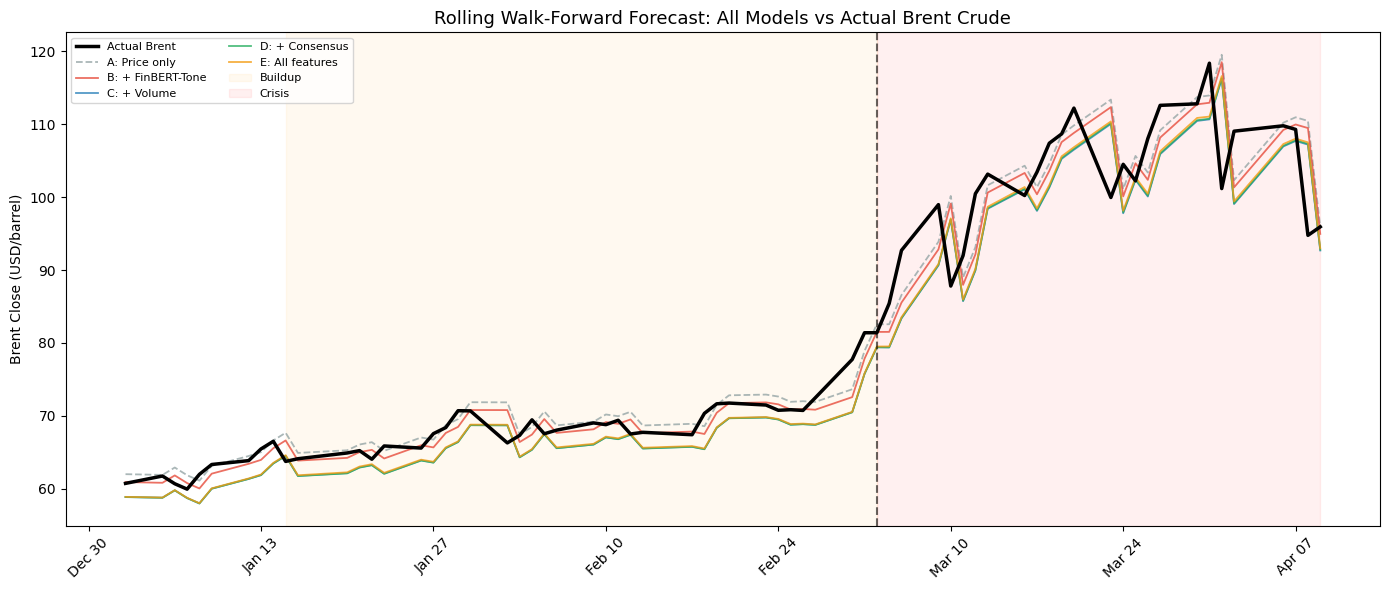

In [31]:
fig, ax = plt.subplots(figsize=(14, 6))

# Actual price
dates = pd.DatetimeIndex(all_results["A_price_only"]["dates"])
actuals = all_results["A_price_only"]["actuals"]
ax.plot(dates, actuals, color="black", linewidth=2.5, label="Actual Brent", zorder=10)

# Model predictions
for name, (label, color, ls) in model_display.items():
    ax.plot(dates, all_results[name]["predictions"],
            color=color, linestyle=ls, linewidth=1.3, alpha=0.8, label=label)

# Regime shading
ax.axvspan(buildup_dt, crisis_dt, alpha=0.06, color="orange", label="Buildup")
ax.axvspan(crisis_dt, dates.max(), alpha=0.06, color="red", label="Crisis")
ax.axvline(crisis_dt, color="black", linestyle="--", linewidth=1.5, alpha=0.6)

ax.set_title("Rolling Walk-Forward Forecast: All Models vs Actual Brent Crude", fontsize=13)
ax.set_ylabel("Brent Close (USD/barrel)")
ax.legend(loc="best", fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plots/prediction_overlay.png", dpi=150)
plt.show()

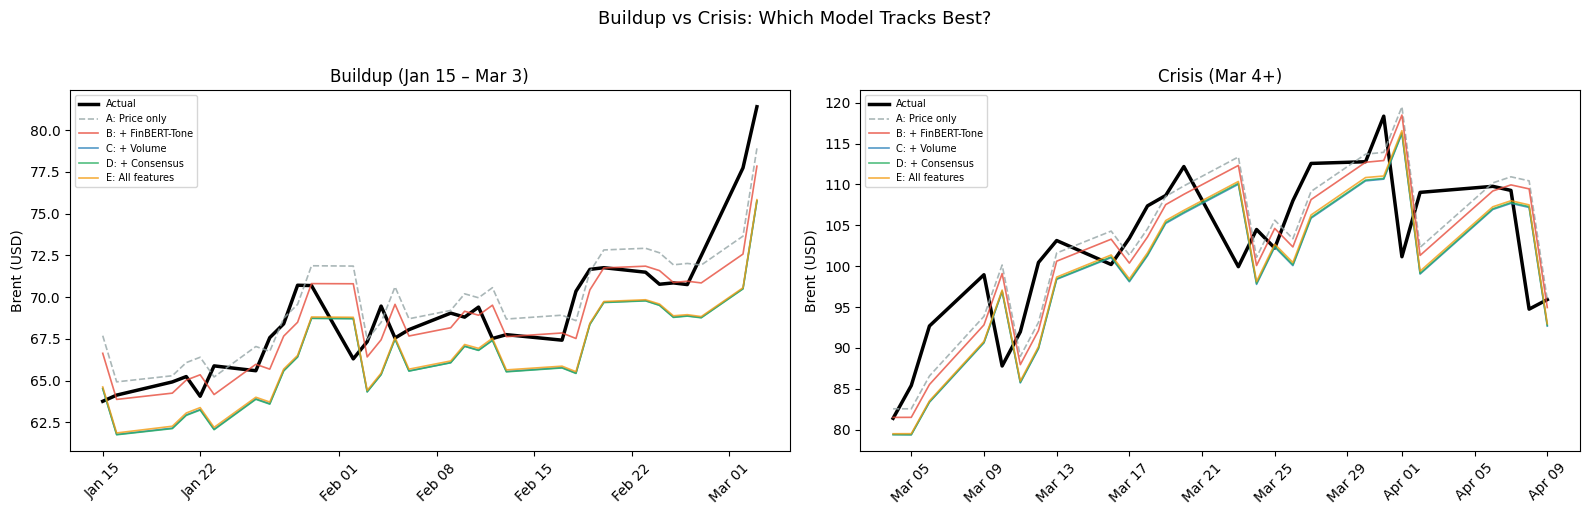

In [32]:
# Side-by-side: Buildup vs Crisis
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (regime, mask_fn, title) in zip(axes, [
    ("buildup", lambda d: (d >= buildup_dt) & (d < crisis_dt), "Buildup (Jan 15 – Mar 3)"),
    ("crisis", lambda d: d >= crisis_dt, "Crisis (Mar 4+)"),
]):
    mask = mask_fn(dates)
    ax.plot(dates[mask], actuals[mask], color="black", linewidth=2.5, label="Actual")
    for name, (label, color, ls) in model_display.items():
        ax.plot(dates[mask], all_results[name]["predictions"][mask],
                color=color, linestyle=ls, linewidth=1.2, alpha=0.8, label=label)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Brent (USD)")
    ax.legend(fontsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.suptitle("Buildup vs Crisis: Which Model Tracks Best?", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("plots/prediction_buildup_vs_crisis.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Error Evolution
Rolling prediction error over time. Where does each model start breaking down?

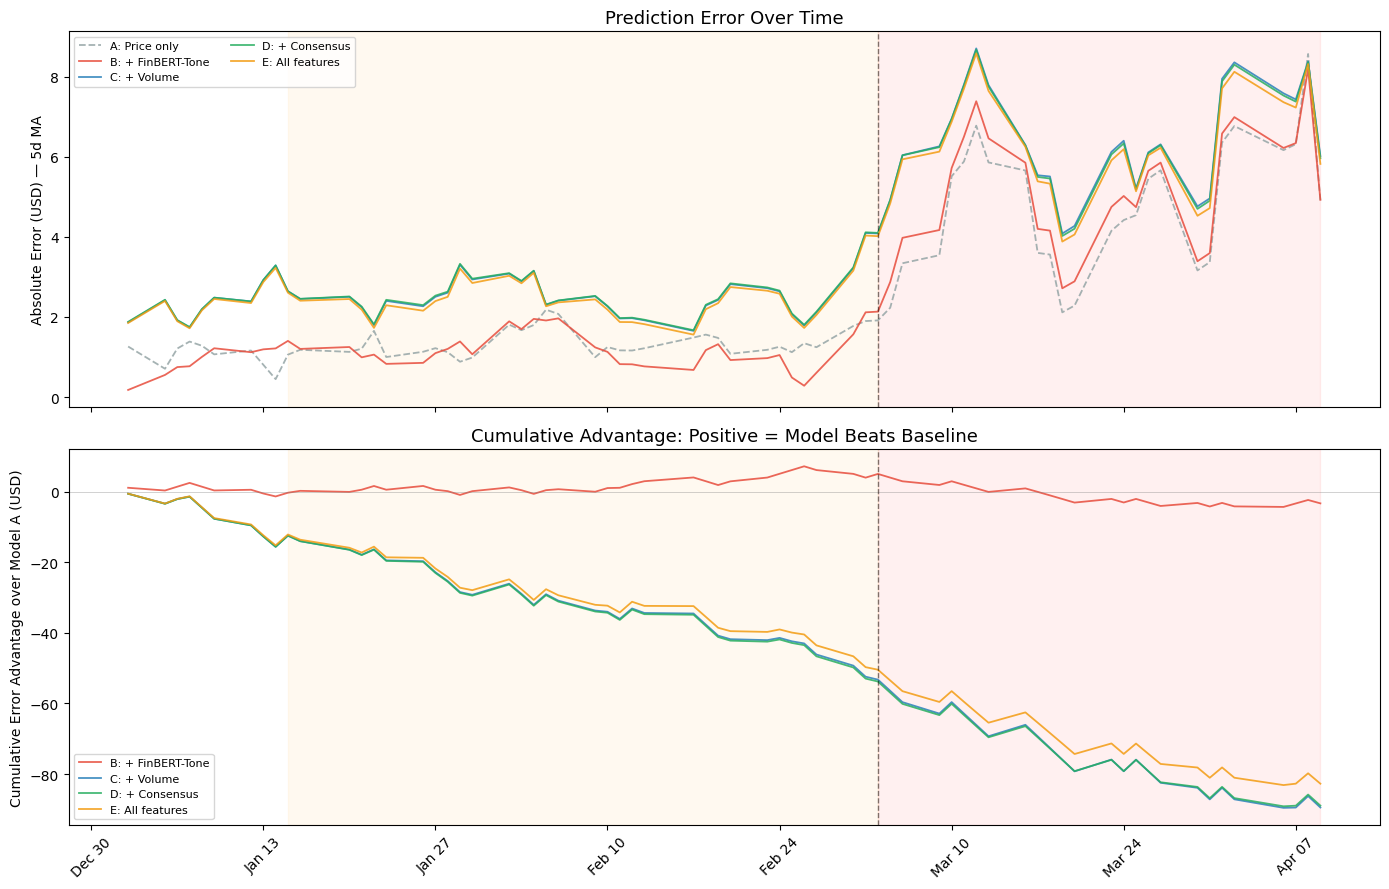

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Panel 1: Rolling absolute error (5-day MA)
ax = axes[0]
for name, (label, color, ls) in model_display.items():
    errors = np.abs(all_results[name]["predictions"] - all_results[name]["actuals"])
    rolling_err = pd.Series(errors, index=dates).rolling(5, min_periods=1).mean()
    ax.plot(dates, rolling_err, color=color, linestyle=ls, linewidth=1.3, label=label, alpha=0.85)

ax.axvspan(buildup_dt, crisis_dt, alpha=0.06, color="orange")
ax.axvspan(crisis_dt, dates.max(), alpha=0.06, color="red")
ax.axvline(crisis_dt, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.set_ylabel("Absolute Error (USD) — 5d MA")
ax.set_title("Prediction Error Over Time", fontsize=13)
ax.legend(fontsize=8, ncol=2)

# Panel 2: Cumulative error advantage over baseline
ax = axes[1]
baseline_errors = np.abs(all_results["A_price_only"]["predictions"] - all_results["A_price_only"]["actuals"])

for name, (label, color, ls) in model_display.items():
    if name == "A_price_only":
        continue
    model_errors = np.abs(all_results[name]["predictions"] - all_results[name]["actuals"])
    # Positive = model is better than baseline, negative = worse
    advantage = np.cumsum(baseline_errors - model_errors)
    ax.plot(dates, advantage, color=color, linestyle=ls, linewidth=1.3, label=label, alpha=0.85)

ax.axhline(0, color="gray", linewidth=0.5, alpha=0.5)
ax.axvspan(buildup_dt, crisis_dt, alpha=0.06, color="orange")
ax.axvspan(crisis_dt, dates.max(), alpha=0.06, color="red")
ax.axvline(crisis_dt, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.set_ylabel("Cumulative Error Advantage over Model A (USD)")
ax.set_title("Cumulative Advantage: Positive = Model Beats Baseline", fontsize=13)
ax.legend(fontsize=8)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plots/error_evolution.png", dpi=150)
plt.show()

---
## 7. Directional Accuracy by Regime
Bar chart comparing each model's ability to predict price direction across regimes.

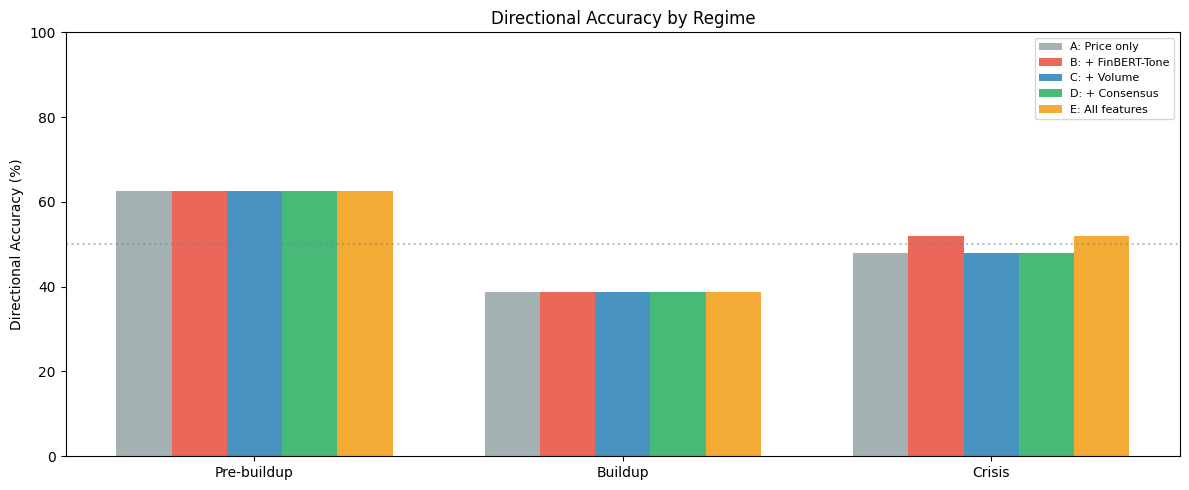

In [34]:
regime_names = ["Pre-buildup", "Buildup", "Crisis"]
model_names = list(MODEL_CONFIGS.keys())

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(regime_names))
width = 0.15

for i, name in enumerate(model_names):
    label, color, _ = model_display[name]
    vals = []
    for regime in regime_names:
        m = regime_metrics.get(name, {}).get(regime, {})
        vals.append(m.get("dir_acc", 0))
    ax.bar(x + i * width, vals, width, label=label, color=color, alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(regime_names)
ax.set_ylabel("Directional Accuracy (%)")
ax.set_title("Directional Accuracy by Regime")
ax.legend(fontsize=8)
ax.axhline(50, color="gray", linestyle=":", alpha=0.5, label="Random (50%)")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig("plots/directional_accuracy.png", dpi=150)
plt.show()

## 8. XGBoost Comparison
Tree-based model as architecture-independent validation.
If XGBoost shows the same pattern (E > A), the finding is about the features, not the architecture.

In [35]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb

print("=" * 60)
print("XGBOOST WALK-FORWARD COMPARISON")
print("=" * 60)

def make_xgb_features(data, lookback):
    """Flatten lookback window into tabular features for XGBoost."""
    X, y = [], []
    for i in range(lookback, len(data) - 1):
        # Flatten the lookback window into one row
        window = data[i - lookback:i].flatten()
        # Target: next-day return (change in col 0)
        target = data[i + 1, 0] - data[i, 0]
        X.append(window)
        y.append(target)
    return np.array(X), np.array(y)

xgb_results = {}

for model_name, features in MODEL_CONFIGS.items():
    print(f"\n{model_name} ({len(features)} features)")
    n_feat = len(features)

    init_mask = df.index < FORECAST_START
    init_data = df.loc[init_mask, features].values
    scaler = MinMaxScaler()
    scaler.fit(init_data)

    predictions = []
    actuals = []
    pred_dates = []

    # Initial training data
    scaled_init = scaler.transform(init_data)
    X_train, y_train = make_xgb_features(scaled_init, LOOKBACK)

    xgb_model = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        verbosity=0,
    )
    xgb_model.fit(X_train, y_train)

    days_since_retrain = 0

    for i, target_date in enumerate(forecast_dates):
        available = df.loc[df.index < target_date, features].values
        if len(available) < LOOKBACK + 1:
            continue

        scaled_available = scaler.transform(available)

        # Retrain periodically
        days_since_retrain += 1
        if days_since_retrain >= RETRAIN_EVERY:
            X_retrain, y_retrain = make_xgb_features(scaled_available, LOOKBACK)
            xgb_model.fit(X_retrain, y_retrain)
            days_since_retrain = 0

        # Predict
        window = scaled_available[-LOOKBACK:].flatten().reshape(1, -1)
        pred_change = xgb_model.predict(window)[0]

        last_scaled = scaled_available[-1, 0]
        pred_scaled = last_scaled + pred_change

        dummy = np.zeros((1, n_feat))
        dummy[0, 0] = pred_scaled
        pred_price = scaler.inverse_transform(dummy)[0, 0]
        actual_price = df.loc[target_date, "brent_close"]

        predictions.append(pred_price)
        actuals.append(actual_price)
        pred_dates.append(target_date)

    xgb_results[model_name] = {
        "dates": pred_dates,
        "predictions": np.array(predictions),
        "actuals": np.array(actuals),
    }

    # Quick metrics
    preds_arr = np.array(predictions)
    acts_arr = np.array(actuals)
    dates_arr = pd.DatetimeIndex(pred_dates)
    crisis_mask = dates_arr >= crisis_dt
    rmse_crisis = np.sqrt(np.mean((acts_arr[crisis_mask] - preds_arr[crisis_mask])**2))
    rmse_full = np.sqrt(np.mean((acts_arr - preds_arr)**2))
    print(f"  Crisis RMSE: ${rmse_crisis:.2f} | Full RMSE: ${rmse_full:.2f}")

XGBOOST WALK-FORWARD COMPARISON

A_price_only (6 features)
  Crisis RMSE: $6.98 | Full RMSE: $4.57

B_sentiment (7 features)
  Crisis RMSE: $7.08 | Full RMSE: $4.62

C_volume (8 features)
  Crisis RMSE: $6.89 | Full RMSE: $4.52

D_consensus (8 features)
  Crisis RMSE: $6.87 | Full RMSE: $4.51

E_all (15 features)
  Crisis RMSE: $6.91 | Full RMSE: $4.52


## Persistence Baseline
Naive model: tomorrow's price = today's price

In [36]:
print("\nPERSISTENCE BASELINE (predict yesterday's price)")
persist_preds = []
persist_actuals = []
persist_dates = []

for target_date in forecast_dates:
    available = df.loc[df.index < target_date, "brent_close"]
    if len(available) < 1:
        continue
    persist_preds.append(available.iloc[-1])
    persist_actuals.append(df.loc[target_date, "brent_close"])
    persist_dates.append(target_date)

persist_preds = np.array(persist_preds)
persist_actuals = np.array(persist_actuals)
persist_dates_arr = pd.DatetimeIndex(persist_dates)

crisis_mask = persist_dates_arr >= crisis_dt
buildup_mask = (persist_dates_arr >= buildup_dt) & (persist_dates_arr < crisis_dt)

persist_rmse_crisis = np.sqrt(np.mean((persist_actuals[crisis_mask] - persist_preds[crisis_mask])**2))
persist_rmse_buildup = np.sqrt(np.mean((persist_actuals[buildup_mask] - persist_preds[buildup_mask])**2))
persist_rmse_full = np.sqrt(np.mean((persist_actuals - persist_preds)**2))
print(f"  Buildup RMSE: ${persist_rmse_buildup:.2f} | Crisis RMSE: ${persist_rmse_crisis:.2f} | Full RMSE: ${persist_rmse_full:.2f}")


PERSISTENCE BASELINE (predict yesterday's price)
  Buildup RMSE: $1.87 | Crisis RMSE: $6.82 | Full RMSE: $4.46


### Cross-Architecture Comparison Table

In [37]:
print("\n" + "=" * 90)
print("CROSS-ARCHITECTURE COMPARISON (Crisis Period)")
print("=" * 90)
print(f"{'Model':<22s} {'Persistence':>12s} {'LSTM':>12s} {'XGBoost':>12s}")
print("-" * 60)

for model_name in MODEL_CONFIGS:
    label = model_display[model_name][0] if model_name in model_display else model_name

    # LSTM (from original all_results)
    lstm_dates = pd.DatetimeIndex(all_results[model_name]["dates"])
    lstm_crisis = lstm_dates >= crisis_dt
    lstm_rmse = np.sqrt(np.mean(
        (all_results[model_name]["actuals"][lstm_crisis] - all_results[model_name]["predictions"][lstm_crisis])**2
    ))

    # XGBoost
    xgb_dates = pd.DatetimeIndex(xgb_results[model_name]["dates"])
    xgb_crisis = xgb_dates >= crisis_dt
    xgb_rmse = np.sqrt(np.mean(
        (xgb_results[model_name]["actuals"][xgb_crisis] - xgb_results[model_name]["predictions"][xgb_crisis])**2
    ))

    print(f"{label:<22s} ${persist_rmse_crisis:>10.2f} ${lstm_rmse:>10.2f} ${xgb_rmse:>10.2f}")

print(f"\n{'Persistence baseline':22s} ${persist_rmse_crisis:>10.2f}")
print(f"\nIf Model E beats Model A on BOTH architectures,")
print(f"the finding is about the features, not the model.")


CROSS-ARCHITECTURE COMPARISON (Crisis Period)
Model                   Persistence         LSTM      XGBoost
------------------------------------------------------------
A: Price only          $      6.82 $      6.83 $      6.98
B: + FinBERT-Tone      $      6.82 $      6.81 $      7.08
C: + Volume            $      6.82 $      7.30 $      6.89
D: + Consensus         $      6.82 $      7.27 $      6.87
E: All features        $      6.82 $      7.20 $      6.91

Persistence baseline   $      6.82

If Model E beats Model A on BOTH architectures,
the finding is about the features, not the model.


## 10. Bootstrap Confidence Intervals
1000-iteration bootstrap on crisis-period errors to test if Model E significantly beats Model A.


In [38]:
from scipy import stats as scipy_stats

N_BOOTSTRAP = 1000
np.random.seed(42)

print("=" * 60)
print(f"BOOTSTRAP CONFIDENCE INTERVALS ({N_BOOTSTRAP} iterations)")
print("=" * 60)

# Use LSTM results from first run
dates_arr = pd.DatetimeIndex(all_results["A_price_only"]["dates"])

def bootstrap_rmse_diff(errors_a, errors_b, n_iter=1000):
    """Bootstrap the RMSE difference (A - B). Positive = B is better."""
    diffs = []
    n = len(errors_a)
    for _ in range(n_iter):
        idx = np.random.randint(0, n, size=n)
        rmse_a = np.sqrt(np.mean(errors_a[idx]**2))
        rmse_b = np.sqrt(np.mean(errors_b[idx]**2))
        diffs.append(rmse_a - rmse_b)
    return np.array(diffs)

# Get errors for each model in each regime
for regime_name, mask_fn in [
    ("Buildup", lambda d: (d >= buildup_dt) & (d < crisis_dt)),
    ("Crisis", lambda d: d >= crisis_dt),
    ("Full Period", lambda d: d == d),
]:
    mask = mask_fn(dates_arr)
    if mask.sum() < 5:
        continue

    print(f"\n{regime_name} (n={mask.sum()}):")
    print(f"  {'Model':<22s} {'RMSE':>8s} {'vs A diff':>10s} {'95% CI':>20s} {'Significant?':>14s}")
    print("  " + "-" * 76)

    errors_a = all_results["A_price_only"]["actuals"][mask] - all_results["A_price_only"]["predictions"][mask]
    rmse_a = np.sqrt(np.mean(errors_a**2))

    for model_name in MODEL_CONFIGS:
        label = model_display[model_name][0] if model_name in model_display else model_name
        errors_m = all_results[model_name]["actuals"][mask] - all_results[model_name]["predictions"][mask]
        rmse_m = np.sqrt(np.mean(errors_m**2))

        if model_name == "A_price_only":
            print(f"  {label:<22s} ${rmse_m:>6.2f}   {'baseline':>10s} {'':>20s} {'':>14s}")
            continue

        # Bootstrap difference
        diffs = bootstrap_rmse_diff(errors_a, errors_m, N_BOOTSTRAP)
        ci_low = np.percentile(diffs, 2.5)
        ci_high = np.percentile(diffs, 97.5)
        mean_diff = np.mean(diffs)

        # Significant if CI doesn't cross zero
        sig = "YES *" if (ci_low > 0 or ci_high < 0) else "no"
        direction = "better" if mean_diff > 0 else "worse"

        print(f"  {label:<22s} ${rmse_m:>6.2f}   {mean_diff:>+9.2f}   [{ci_low:>+7.2f}, {ci_high:>+7.2f}]   {sig:>12s} ({direction})")


BOOTSTRAP CONFIDENCE INTERVALS (1000 iterations)

Buildup (n=32):
  Model                      RMSE  vs A diff               95% CI   Significant?
  ----------------------------------------------------------------------------
  A: Price only          $  1.94     baseline                                    
  B: + FinBERT-Tone      $  1.85       +0.09   [  -0.25,   +0.44]             no (better)
  C: + Volume            $  3.04       -1.11   [  -1.81,   -0.33]          YES * (worse)
  D: + Consensus         $  3.05       -1.14   [  -1.86,   -0.37]          YES * (worse)
  E: All features        $  2.97       -1.02   [  -1.75,   -0.24]          YES * (worse)

Crisis (n=26):
  Model                      RMSE  vs A diff               95% CI   Significant?
  ----------------------------------------------------------------------------
  A: Price only          $  6.83     baseline                                    
  B: + FinBERT-Tone      $  6.81       -0.01   [  -0.46,   +0.34]            

### Summary Visualization

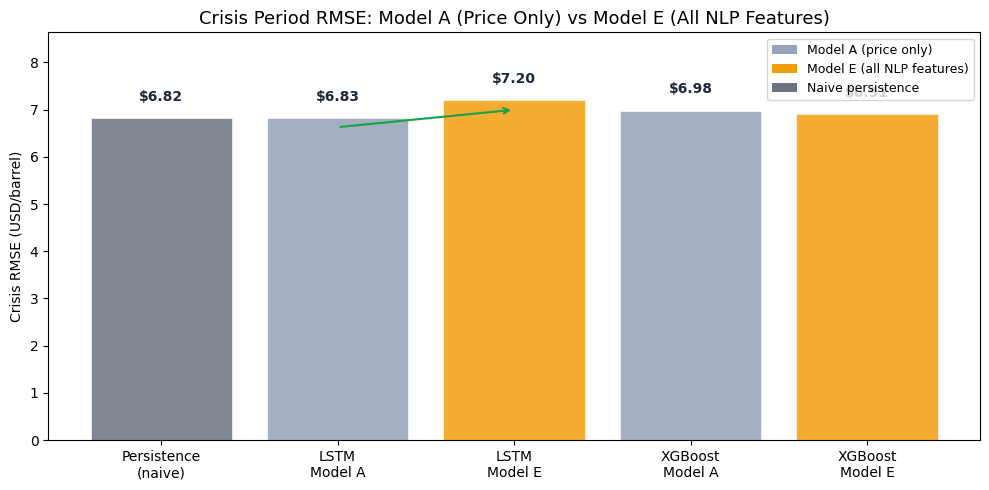

In [39]:
# Bar chart: Crisis RMSE across all architectures for Model A vs E

fig, ax = plt.subplots(figsize=(10, 5))

categories = ["Persistence\n(naive)", "LSTM\nModel A", "LSTM\nModel E", "XGBoost\nModel A", "XGBoost\nModel E"]

# Gather values
lstm_a_crisis = np.sqrt(np.mean((all_results["A_price_only"]["actuals"][dates_arr >= crisis_dt] -
                                  all_results["A_price_only"]["predictions"][dates_arr >= crisis_dt])**2))
lstm_e_crisis = np.sqrt(np.mean((all_results["E_all"]["actuals"][dates_arr >= crisis_dt] -
                                  all_results["E_all"]["predictions"][dates_arr >= crisis_dt])**2))

xgb_a_dates = pd.DatetimeIndex(xgb_results["A_price_only"]["dates"])
xgb_e_dates = pd.DatetimeIndex(xgb_results["E_all"]["dates"])
xgb_a_crisis = np.sqrt(np.mean((xgb_results["A_price_only"]["actuals"][xgb_a_dates >= crisis_dt] -
                                 xgb_results["A_price_only"]["predictions"][xgb_a_dates >= crisis_dt])**2))
xgb_e_crisis = np.sqrt(np.mean((xgb_results["E_all"]["actuals"][xgb_e_dates >= crisis_dt] -
                                  xgb_results["E_all"]["predictions"][xgb_e_dates >= crisis_dt])**2))

values = [persist_rmse_crisis, lstm_a_crisis, lstm_e_crisis, xgb_a_crisis, xgb_e_crisis]
bar_colors = ["#6b7280", "#94a3b8", "#f59e0b", "#94a3b8", "#f59e0b"]

bars = ax.bar(categories, values, color=bar_colors, edgecolor="white", linewidth=0.5, alpha=0.85)

# Value labels
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"${v:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold", color="#1e293b")

# Annotations
ax.annotate("", xy=(2, lstm_e_crisis - 0.2), xytext=(1, lstm_a_crisis - 0.2),
            arrowprops=dict(arrowstyle="->", color="#16a34a", lw=1.5))

ax.set_ylabel("Crisis RMSE (USD/barrel)")
ax.set_title("Crisis Period RMSE: Model A (Price Only) vs Model E (All NLP Features)", fontsize=13)
ax.set_ylim(0, max(values) * 1.2)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#94a3b8", label="Model A (price only)"),
                   Patch(facecolor="#f59e0b", label="Model E (all NLP features)"),
                   Patch(facecolor="#6b7280", label="Naive persistence")]
ax.legend(handles=legend_elements, fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig("plots/cross_architecture_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


### Multi-seed stability visualization

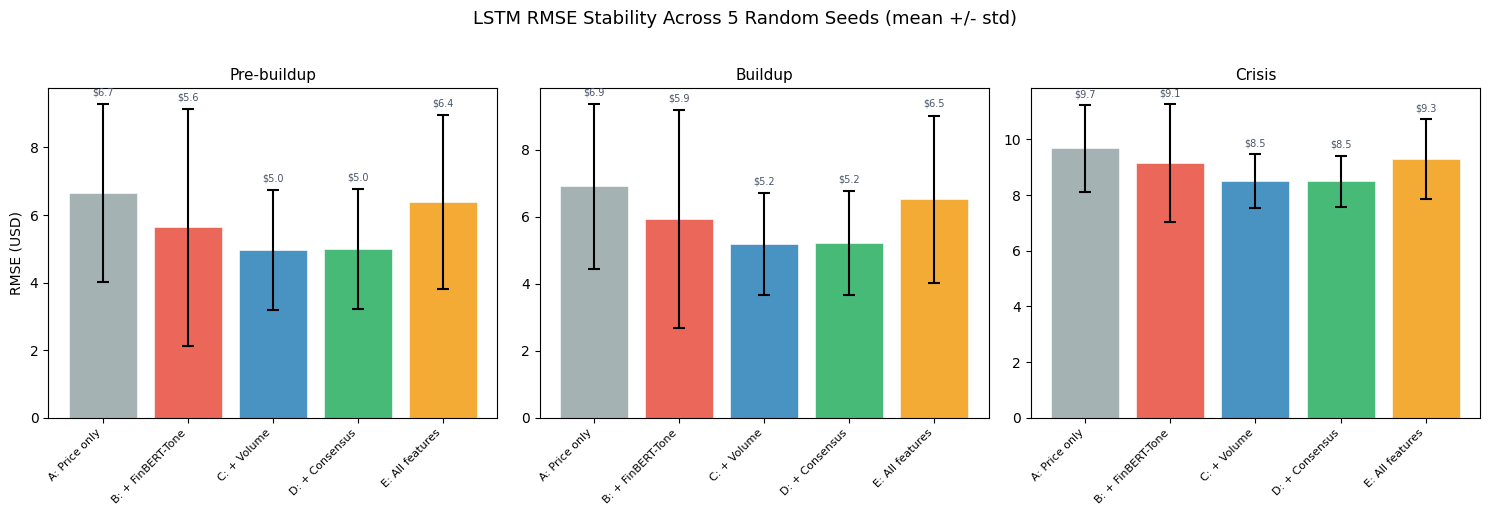


Done. New plots saved to plots/cross_architecture_comparison.png and plots/multi_seed_stability.png


In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, regime, regime_key in zip(axes, ["Pre-buildup", "Buildup", "Crisis"],
                                         ["pre_buildup", "buildup", "crisis"]):
    model_names = list(MODEL_CONFIGS.keys())
    means = [np.mean(seed_results[m]["rmses"][regime_key]) for m in model_names]
    stds = [np.std(seed_results[m]["rmses"][regime_key]) for m in model_names]
    x_labels = [model_display[m][0] for m in model_names]
    x_colors = [model_display[m][1] for m in model_names]

    bars = ax.bar(range(len(model_names)), means, yerr=stds, capsize=4,
                  color=x_colors, alpha=0.85, edgecolor="white", linewidth=0.5,
                  error_kw={"elinewidth": 1.5, "capthick": 1.5, "color": "#1e293b"})

    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("RMSE (USD)" if ax == axes[0] else "")
    ax.set_title(f"{regime}", fontsize=11)

    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.2,
                f"${m:.1f}", ha="center", va="bottom", fontsize=7, color="#475569")

plt.suptitle(f"LSTM RMSE Stability Across {NUM_SEEDS} Random Seeds (mean +/- std)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("plots/multi_seed_stability.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nDone. New plots saved to plots/cross_architecture_comparison.png and plots/multi_seed_stability.png")
